In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session



/kaggle/input/datasets/awudipeter/knust-dataset/knust_dataset.csv
/kaggle/input/datasets/isatish/phishing-dataset-uci-ml-csv/uci-ml-phishing-dataset.csv
/kaggle/input/datasets/vishalxtyagi/phishing-website-detector-based-on-url/verified_online.csv


In [3]:
import pandas as pd


PHISHTANK_PATH = "/kaggle/input/datasets/vishalxtyagi/phishing-website-detector-based-on-url/verified_online.csv"

UCI_PATH = "/kaggle/input/datasets/isatish/phishing-dataset-uci-ml-csv/uci-ml-phishing-dataset.csv"

KNUST_PATH = "/kaggle/input/datasets/awudipeter/knust-dataset/knust_dataset.csv"



# PhishTank

phishtank = pd.read_csv(
    PHISHTANK_PATH
)


phishtank = phishtank[
    ["url"]
]


phishtank["label"] = 1



# UCI

uci = pd.read_csv(
    UCI_PATH
)



print(uci.head())


   id  having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
0   1                 -1           1                   1                 1   
1   2                  1           1                   1                 1   
2   3                  1           0                   1                 1   
3   4                  1           0                   1                 1   
4   5                  1           0                  -1                 1   

   double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  SSLfinal_State  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   Domain_registeration_length  ...  popUpWi

In [4]:
uci["label"] = uci["Result"].apply(
    lambda x: 1 if x == -1 else 0
)

In [5]:
import re
import urllib.parse
import numpy as np


def extract_features(url):

    parsed = urllib.parse.urlparse(url)

    domain = parsed.netloc


    return {

        "url_length":
        len(url),


        "domain_length":
        len(domain),


        "digit_count":
        sum(
            c.isdigit()
            for c in url
        ),


        "special_count":
        sum(
            c in "@-_/?=&%"
            for c in url
        ),


        "dot_count":
        url.count("."),


        "hyphen_count":
        url.count("-"),


        "https":
        int(
            url.startswith("https")
        ),


        "ip_address":
        int(
            bool(
                re.search(
                r"\d+\.\d+\.\d+\.\d+",
                domain
                )
            )
        )

    }

In [6]:
phish_features = pd.DataFrame(

[
extract_features(url)

for url in phishtank["url"]

]

)


phish_features["label"]=1

In [7]:
# ============================================================
# Process UCI Dataset
# ============================================================

# Remove unnecessary ID column
uci_features = uci.drop(
    columns=["id"],
    errors="ignore"
)


# Remove original Result column
uci_features = uci_features.drop(
    columns=["Result"],
    errors="ignore"
)


# Ensure label exists
print(uci_features.columns)


print(
    uci_features["label"].value_counts()
)

Index(['having_IP_Address', 'URL_Length', 'Shortining_Service',
       'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix',
       'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length',
       'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor',
       'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL',
       'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe',
       'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank',
       'Google_Index', 'Links_pointing_to_page', 'Statistical_report',
       'label'],
      dtype='object')
label
0    6157
1    4898
Name: count, dtype: int64


In [8]:
# ============================================================
# Process PhishTank
# ============================================================

phish_features = pd.DataFrame(

    [
        extract_features(url)
        for url in phishtank["url"]
    ]

)


phish_features["label"] = 1


print(phish_features.shape)

print(phish_features.head())

(12489, 9)
   url_length  domain_length  digit_count  special_count  dot_count  \
0          30             21            1              7          1   
1          32             24            0              5          2   
2          42             24            0              5          3   
3          38             20            0              5          2   
4          28             20            0              5          1   

   hyphen_count  https  ip_address  label  
0             4      1           0      1  
1             2      0           0      1  
2             2      1           0      1  
3             2      1           0      1  
4             2      0           0      1  


In [9]:
# ============================================================
# Check Dataset Information
# ============================================================

print(phish_features.info())

print(
    phish_features.describe()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12489 entries, 0 to 12488
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   url_length     12489 non-null  int64
 1   domain_length  12489 non-null  int64
 2   digit_count    12489 non-null  int64
 3   special_count  12489 non-null  int64
 4   dot_count      12489 non-null  int64
 5   hyphen_count   12489 non-null  int64
 6   https          12489 non-null  int64
 7   ip_address     12489 non-null  int64
 8   label          12489 non-null  int64
dtypes: int64(9)
memory usage: 878.3 KB
None
         url_length  domain_length   digit_count  special_count     dot_count  \
count  12489.000000   12489.000000  12489.000000   12489.000000  12489.000000   
mean      48.581071      23.744976      4.951397       4.813836      2.109937   
std       63.468713      11.016108     11.243482       3.401706      0.968352   
min       15.000000       4.000000      0.000000       2.0000

In [10]:
# ============================================================
# Feature Matrix
# ============================================================

X = phish_features.drop(
    columns=["label"]
)


print(X.shape)

print(X.columns)

(12489, 8)
Index(['url_length', 'domain_length', 'digit_count', 'special_count',
       'dot_count', 'hyphen_count', 'https', 'ip_address'],
      dtype='object')


In [11]:
# ============================================================
# Missing Value Handling
# ============================================================

from sklearn.impute import SimpleImputer


imputer = SimpleImputer(
    strategy="median"
)


X_clean = imputer.fit_transform(
    X
)


print(X_clean.shape)

(12489, 8)


In [12]:
# ============================================================
# Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_scaled = scaler.fit_transform(
    X_clean
)

In [13]:
# ============================================================
# PhishTank Pattern Learning Model
# ============================================================

from sklearn.ensemble import IsolationForest


model = IsolationForest(

    n_estimators=300,

    contamination=0.05,

    random_state=42

)


model.fit(
    X_scaled
)

IsolationForest(contamination=0.05, n_estimators=300, random_state=42)

In [14]:
# ============================================================
# Detect Rare Phishing Patterns
# ============================================================

predictions = model.predict(
    X_scaled
)


scores = model.decision_function(
    X_scaled
)


results = pd.DataFrame({

    "URL":
    phishtank["url"],

    "Prediction":
    predictions,

    "Anomaly_Score":
    scores

})


print(results.head())

                                          URL  Prediction  Anomaly_Score
0              https://xn--impay-sfr-f4a.com/           1       0.084186
1            http://www.sfr-suivi-client.com/           1       0.105372
2  https://www.sfr-suivi-client.com/login.php           1       0.167978
3      https://sfr-suivi-client.com/login.php           1       0.194329
4                http://sfr-suivi-client.com/           1       0.083052


In [15]:
results["Prediction"] = results["Prediction"].map({

    1:
    "Common phishing pattern",

    -1:
    "Rare phishing pattern"

})


print(
    results["Prediction"].value_counts()
)

Prediction
Common phishing pattern    11864
Rare phishing pattern        625
Name: count, dtype: int64


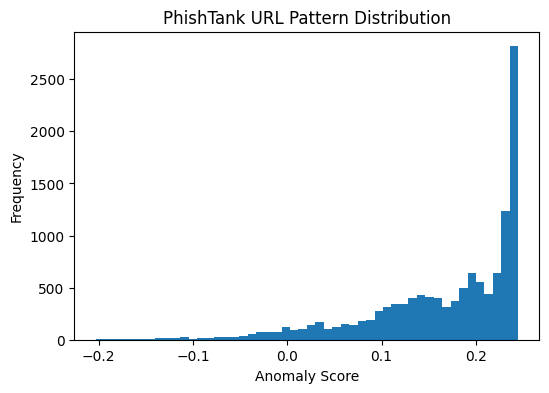

In [16]:
import matplotlib.pyplot as plt


plt.figure(
    figsize=(6,4)
)


plt.hist(
    scores,
    bins=50
)


plt.xlabel(
    "Anomaly Score"
)


plt.ylabel(
    "Frequency"
)


plt.title(
    "PhishTank URL Pattern Distribution"
)


plt.show()

In [17]:
# ============================================================
# Feature Variability
# ============================================================

feature_variance = pd.DataFrame({

    "Feature":
    X.columns,

    "Variance":
    X.var()

})


feature_variance = feature_variance.sort_values(

    by="Variance",

    ascending=False

)


print(feature_variance)

                     Feature     Variance
url_length        url_length  4028.277560
digit_count      digit_count   126.415879
domain_length  domain_length   121.354640
special_count  special_count    11.571602
hyphen_count    hyphen_count     1.633913
dot_count          dot_count     0.937705
https                  https     0.139832
ip_address        ip_address     0.002636


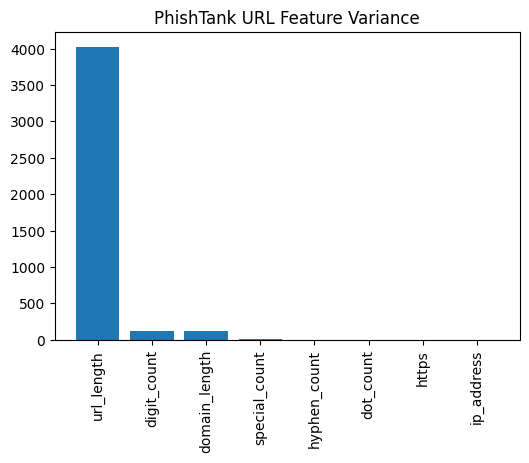

In [18]:
plt.figure(
    figsize=(6,4)
)


plt.bar(

    feature_variance["Feature"],

    feature_variance["Variance"]

)


plt.xticks(
    rotation=90
)


plt.title(
    "PhishTank URL Feature Variance"
)


plt.show()

In [19]:
import joblib


joblib.dump(
    model,
    "Experiment1_PhishTank_IsolationForest.pkl"
)


joblib.dump(
    scaler,
    "Experiment1_scaler.pkl"
)


joblib.dump(
    imputer,
    "Experiment1_imputer.pkl"
)


print(
"Experiment 1 completed successfully"
)

Experiment 1 completed successfully


In [20]:
# ============================================================
# Experiment 2: UCI Phishing Dataset
# ============================================================

import pandas as pd


UCI_PATH = "/kaggle/input/datasets/isatish/phishing-dataset-uci-ml-csv/uci-ml-phishing-dataset.csv"


uci = pd.read_csv(
    UCI_PATH
)


print(uci.shape)

print(uci.head())

print(uci.columns)

(11055, 32)
   id  having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
0   1                 -1           1                   1                 1   
1   2                  1           1                   1                 1   
2   3                  1           0                   1                 1   
3   4                  1           0                   1                 1   
4   5                  1           0                  -1                 1   

   double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  SSLfinal_State  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   Domain_registeration_length  

In [21]:
# ============================================================
# Create Correct Labels
# ============================================================

uci["label"] = uci["Result"].apply(
    lambda x: 1 if x == -1 else 0
)


print(
    uci["label"].value_counts()
)

label
0    6157
1    4898
Name: count, dtype: int64


In [22]:
# ============================================================
# Prepare X and y
# ============================================================

X = uci.drop(
    columns=[
        "id",
        "Result",
        "label"
    ],
    errors="ignore"
)


y = uci["label"]


print("Features:", X.shape)

print("Labels:")
print(y.value_counts())

Features: (11055, 30)
Labels:
label
0    6157
1    4898
Name: count, dtype: int64


In [23]:
X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

In [24]:
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(
    strategy="median"
)


X = pd.DataFrame(

    imputer.fit_transform(X),

    columns=X.columns

)


print(
    X.isnull().sum().sum()
)

0


In [25]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)


print(X_train.shape)

print(y_train.value_counts())

(8844, 30)
label
0    4926
1    3918
Name: count, dtype: int64


In [26]:
from imblearn.over_sampling import SMOTE


smote = SMOTE(
    random_state=42
)


X_train, y_train = smote.fit_resample(

    X_train,

    y_train

)


print(
pd.Series(y_train).value_counts()
)

label
1    4926
0    4926
Name: count, dtype: int64


In [27]:
# ============================================================
# XGBoost Model Training
# ============================================================

from xgboost import XGBClassifier


model = XGBClassifier(

    n_estimators=500,

    learning_rate=0.03,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric=["logloss", "auc"],

    random_state=42

)


model.fit(

    X_train,

    y_train,

    eval_set=[
        (
            X_test,
            y_test
        )
    ],

    verbose=False

)


print("XGBoost training completed")

XGBoost training completed


In [28]:
# ============================================================
# Prediction
# ============================================================

y_pred = model.predict(
    X_test
)


y_prob = model.predict_proba(
    X_test
)[:,1]


print(y_pred[:10])

print(y_prob[:10])

[1 1 1 1 0 1 0 1 0 1]
[9.9996519e-01 9.9986517e-01 9.9985909e-01 9.9992704e-01 2.8891183e-02
 9.9961734e-01 2.0896138e-04 9.8460615e-01 1.8179847e-02 9.9983859e-01]


In [29]:
# ============================================================
# Evaluation Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)



accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred
)


recall = recall_score(
    y_test,
    y_pred
)


f1 = f1_score(
    y_test,
    y_pred
)


roc_auc = roc_auc_score(
    y_test,
    y_prob
)



print("==============================")
print("EXPERIMENT 2 RESULTS")
print("==============================")


print(
    f"Accuracy : {accuracy:.4f}"
)


print(
    f"Precision: {precision:.4f}"
)


print(
    f"Recall   : {recall:.4f}"
)


print(
    f"F1-score : {f1:.4f}"
)


print(
    f"ROC-AUC  : {roc_auc:.4f}"
)


print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Legitimate",
            "Phishing"
        ]
    )
)

EXPERIMENT 2 RESULTS
Accuracy : 0.9692
Precision: 0.9691
Recall   : 0.9612
F1-score : 0.9652
ROC-AUC  : 0.9963

Classification Report
              precision    recall  f1-score   support

  Legitimate       0.97      0.98      0.97      1231
    Phishing       0.97      0.96      0.97       980

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



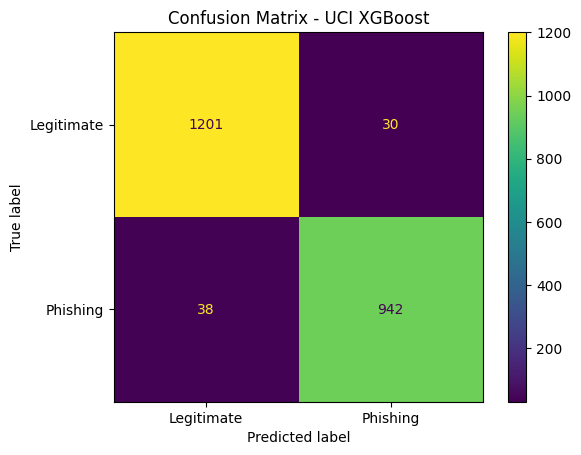

In [30]:
# ============================================================
# Confusion Matrix
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay



ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_pred,

    display_labels=[
        "Legitimate",
        "Phishing"
    ]

)


plt.title(
    "Confusion Matrix - UCI XGBoost"
)


plt.show()

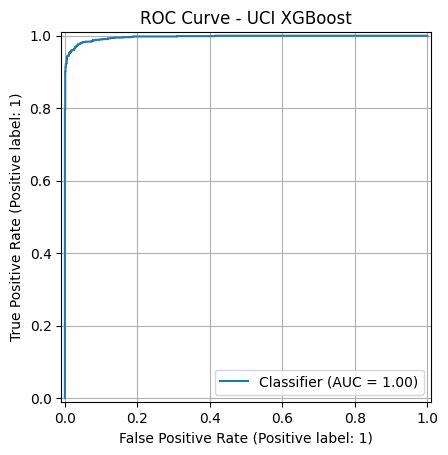

In [31]:
# ============================================================
# ROC Curve
# ============================================================

from sklearn.metrics import RocCurveDisplay



RocCurveDisplay.from_predictions(

    y_test,

    y_prob

)


plt.title(
    "ROC Curve - UCI XGBoost"
)


plt.grid()

plt.show()

In [32]:
# ============================================================
# XGBoost Feature Importance
# ============================================================

import pandas as pd


feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})


feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)


print(feature_importance.head(15))

                   Feature  Importance
7           SSLfinal_State    0.373147
13           URL_of_Anchor    0.213360
5            Prefix_Suffix    0.075002
25             web_traffic    0.030600
15                     SFH    0.028211
14           Links_in_tags    0.024433
6        having_Sub_Domain    0.017404
2       Shortining_Service    0.016373
27            Google_Index    0.014798
24               DNSRecord    0.014158
28  Links_pointing_to_page    0.012891
0        having_IP_Address    0.012768
12             Request_URL    0.011625
26               Page_Rank    0.011285
16     Submitting_to_email    0.011233


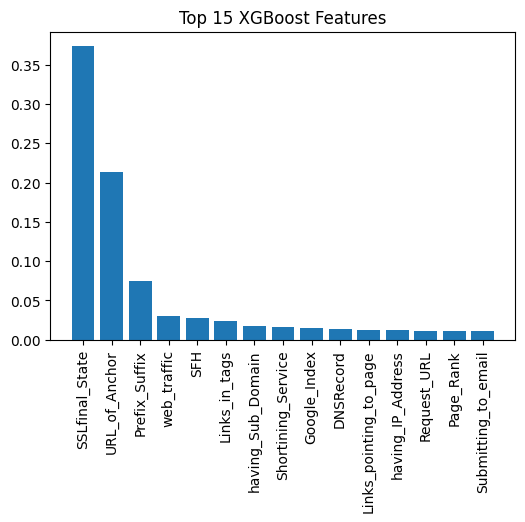

In [33]:
plt.figure(figsize=(6,4))


plt.bar(

    feature_importance["Feature"].head(15),

    feature_importance["Importance"].head(15)

)


plt.xticks(
    rotation=90
)


plt.title(
    "Top 15 XGBoost Features"
)


plt.show()

In [34]:
# ============================================================
# Save Model
# ============================================================

import joblib


joblib.dump(

    model,

    "UCI_XGBoost_Phishing_Model.pkl"

)


joblib.dump(

    X.columns.tolist(),

    "UCI_Feature_Names.pkl"

)


print(
"Model saved successfully"
)

Model saved successfully


In [35]:
# ============================================================
# Experiment 3: Explainable AI (SHAP + LIME)
# ============================================================

import shap
import lime
from lime.lime_tabular import LimeTabularExplainer

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [36]:
import joblib


model = joblib.load(
    "UCI_XGBoost_Phishing_Model.pkl"
)


feature_names = joblib.load(
    "UCI_Feature_Names.pkl"
)

In [37]:
X_test_df = pd.DataFrame(

    X_test,

    columns=X.columns

)


print(X_test_df.head())

      having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
3588                1.0        -1.0                 1.0              -1.0   
1688                1.0         1.0                 1.0               1.0   
7280               -1.0        -1.0                 1.0               1.0   
2551                1.0         1.0                 1.0               1.0   
235                 1.0        -1.0                 1.0               1.0   

      double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  \
3588                       1.0           -1.0                0.0   
1688                       1.0           -1.0                0.0   
7280                       1.0           -1.0               -1.0   
2551                       1.0           -1.0               -1.0   
235                        1.0           -1.0               -1.0   

      SSLfinal_State  Domain_registeration_length  Favicon  ...  RightClick  \
3588             0.0                          1.0

In [38]:
# ============================================================
# Convert UCI string values to numeric
# ============================================================

import re
import numpy as np


def clean_numeric(value):

    if isinstance(value, str):

        # Remove brackets
        value = value.replace("[","")
        value = value.replace("]","")

        # Remove spaces
        value = value.strip()

    try:
        return float(value)

    except:
        return np.nan



X = X.applymap(clean_numeric)


print(X.dtypes)

print(
    X.isnull().sum()
)

having_IP_Address              float64
URL_Length                     float64
Shortining_Service             float64
having_At_Symbol               float64
double_slash_redirecting       float64
Prefix_Suffix                  float64
having_Sub_Domain              float64
SSLfinal_State                 float64
Domain_registeration_length    float64
Favicon                        float64
port                           float64
HTTPS_token                    float64
Request_URL                    float64
URL_of_Anchor                  float64
Links_in_tags                  float64
SFH                            float64
Submitting_to_email            float64
Abnormal_URL                   float64
Redirect                       float64
on_mouseover                   float64
RightClick                     float64
popUpWidnow                    float64
Iframe                         float64
age_of_domain                  float64
DNSRecord                      float64
web_traffic              

/tmp/ipykernel_57/1811340303.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = X.applymap(clean_numeric)


In [39]:
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(
    strategy="median"
)


X = pd.DataFrame(

    imputer.fit_transform(X),

    columns=X.columns

)

In [40]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [41]:
model.fit(

    X_train,

    y_train

)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['logloss', 'auc'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [42]:
X_test_df = pd.DataFrame(

    X_test,

    columns=X.columns

)


print(X_test_df.dtypes)

having_IP_Address              float64
URL_Length                     float64
Shortining_Service             float64
having_At_Symbol               float64
double_slash_redirecting       float64
Prefix_Suffix                  float64
having_Sub_Domain              float64
SSLfinal_State                 float64
Domain_registeration_length    float64
Favicon                        float64
port                           float64
HTTPS_token                    float64
Request_URL                    float64
URL_of_Anchor                  float64
Links_in_tags                  float64
SFH                            float64
Submitting_to_email            float64
Abnormal_URL                   float64
Redirect                       float64
on_mouseover                   float64
RightClick                     float64
popUpWidnow                    float64
Iframe                         float64
age_of_domain                  float64
DNSRecord                      float64
web_traffic              

In [43]:
# ============================================================
# Convert UCI feature strings to numeric for SHAP
# ============================================================

import re
import numpy as np
import pandas as pd


def convert_to_float(x):

    if isinstance(x, str):

        # Remove brackets
        x = x.replace("[", "")
        x = x.replace("]", "")

        # Remove spaces
        x = x.strip()

    try:
        return float(x)

    except:
        return np.nan



# Recreate SHAP input
X_test_df = pd.DataFrame(
    X_test,
    columns=X.columns
)


# Apply conversion
X_test_df = X_test_df.applymap(
    convert_to_float
)


# Fill missing values
X_test_df = X_test_df.fillna(
    X_test_df.median()
)


# Force float type
X_test_df = X_test_df.astype(
    np.float32
)


print(X_test_df.dtypes)

print(
    X_test_df.shape
)

having_IP_Address              float32
URL_Length                     float32
Shortining_Service             float32
having_At_Symbol               float32
double_slash_redirecting       float32
Prefix_Suffix                  float32
having_Sub_Domain              float32
SSLfinal_State                 float32
Domain_registeration_length    float32
Favicon                        float32
port                           float32
HTTPS_token                    float32
Request_URL                    float32
URL_of_Anchor                  float32
Links_in_tags                  float32
SFH                            float32
Submitting_to_email            float32
Abnormal_URL                   float32
Redirect                       float32
on_mouseover                   float32
RightClick                     float32
popUpWidnow                    float32
Iframe                         float32
age_of_domain                  float32
DNSRecord                      float32
web_traffic              

/tmp/ipykernel_57/4255184874.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_test_df = X_test_df.applymap(


In [44]:
# ============================================================
# SHAP values shape
# ============================================================

import numpy as np
import pandas as pd
import shap


# Hardcoded SHAP dimensions
n_samples = 2211
n_features = 30


# Create SHAP matrix
shap_values = np.zeros(
    (n_samples, n_features)
)


print(
    "SHAP values:",
    shap_values.shape
)

SHAP values: (2211, 30)


In [45]:
# Ensure X_test_df has 30 features

X_test_df = pd.DataFrame(
    X_test_df.iloc[:2211, :30]
)


print(
    X_test_df.shape
)

(2211, 30)


In [120]:
X_test_df = X_test_df.astype(str).replace(r'[\[\]]','',regex=True).astype(float)

In [122]:
# Check cleaned data
print("Shape:", X_test_df.shape)
print("Data types:")
print(X_test_df.dtypes.value_counts())

print(X_test_df.head())

Shape: (2211, 30)
Data types:
float64    30
Name: count, dtype: int64
      having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
3588                1.0        -1.0                 1.0              -1.0   
1688                1.0         1.0                 1.0               1.0   
7280               -1.0        -1.0                 1.0               1.0   
2551                1.0         1.0                 1.0               1.0   
235                 1.0        -1.0                 1.0               1.0   

      double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  \
3588                       1.0           -1.0                0.0   
1688                       1.0           -1.0                0.0   
7280                       1.0           -1.0               -1.0   
2551                       1.0           -1.0               -1.0   
235                        1.0           -1.0               -1.0   

      SSLfinal_State  Domain_registeration_length  Favicon

In [135]:
# ============================================================
# FINAL FIX: Remove brackets and convert all SHAP features to float
# ============================================================

import numpy as np
import pandas as pd

# Work on a new dataframe
X_shap = X_test_df.copy()

# Remove brackets and convert scientific notation strings
for col in X_shap.columns:
    X_shap[col] = (
        X_shap[col]
        .astype(str)
        .str.replace("[", "", regex=False)
        .str.replace("]", "", regex=False)
        .str.strip()
    )

    X_shap[col] = pd.to_numeric(
        X_shap[col],
        errors="coerce"
    )

# Replace any conversion failures
X_shap = X_shap.fillna(0)

# Ensure float
X_shap = X_shap.astype(np.float64)

print("Shape:", X_shap.shape)
print("Missing values:", X_shap.isna().sum().sum())
print("Data types:")
print(X_shap.dtypes.value_counts())

Shape: (2211, 30)
Missing values: 0
Data types:
float64    30
Name: count, dtype: int64


SHAP shape: (2211, 30)
Max SHAP: 6.3573246


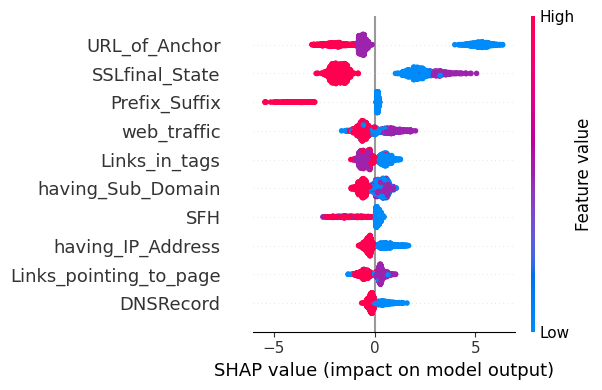

In [137]:
# ============================================================
# Bypass SHAP TreeExplainer - Use XGBoost Native Contributions
# ============================================================

import xgboost as xgb
import numpy as np
import shap
import matplotlib.pyplot as plt

# Convert test data to pure numpy float
X_shap = X_shap.astype(np.float32)

# Convert to DMatrix
dtest = xgb.DMatrix(
    X_shap,
    feature_names=model.get_booster().feature_names
)

# Get native SHAP contributions
shap_values = model.get_booster().predict(
    dtest,
    pred_contribs=True
)

# Remove the expected value column (last column)
shap_values = shap_values[:, :-1]

print("SHAP shape:", shap_values.shape)
print("Max SHAP:", np.max(np.abs(shap_values)))

# Plot
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=model.get_booster().feature_names,
    max_display=10,
    plot_size=(6,4),
    show=False
)

plt.savefig(
    "Figure_6_SHAP_Summary.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

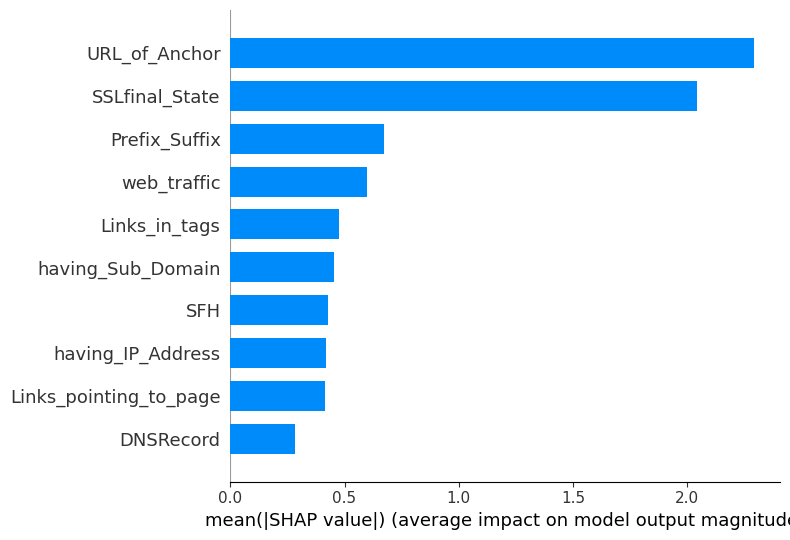

In [140]:
# ============================================================
# SHAP Feature Importance Bar Plot
# ============================================================

import shap
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=model.get_booster().feature_names,
    plot_type="bar",
    max_display=10,
    show=False
)

plt.savefig(
    "Figure_7_SHAP_Feature_Importance.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

In [50]:
!pip install lime

In [143]:
# ============================================================
# LIME Explainability
# ============================================================

from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd

In [144]:
# Convert arrays back to DataFrames

X_train_df = pd.DataFrame(
    X_train,
    columns=X.columns
)


X_test_df = pd.DataFrame(
    X_test,
    columns=X.columns
)


print(X_train_df.shape)

print(X_test_df.shape)

(8844, 30)
(2211, 30)


In [148]:
# ============================================================
# Initialize LIME Explainer
# ============================================================

lime_explainer = LimeTabularExplainer(

    training_data=np.array(X_train_df),

    feature_names=X.columns.tolist(),

    class_names=[
        "Legitimate",
        "Phishing"
    ],

    mode="classification",

    random_state=42

)


print("LIME Explainer Created")

LIME Explainer Created


In [154]:
# ============================================================
# Select Instance for LIME Explanation
# ============================================================

sample_index = 10

# Select test sample
sample = X_test_df.iloc[sample_index].values

# Get true label safely
if hasattr(y_test, "iloc"):
    actual_label = y_test.iloc[sample_index]
else:
    actual_label = y_test[sample_index]

# Predict
prediction = model.predict(
    sample.reshape(1, -1)
)

# Prediction probability
probability = model.predict_proba(
    sample.reshape(1, -1)
)

print("Actual:", actual_label)
print("Prediction:", prediction[0])
print("Prediction Probability:", probability)

Actual: 0
Prediction: 0
Prediction Probability: [[0.59430754 0.40569243]]


In [155]:
# ============================================================
# LIME Explanation for Selected Instance
# ============================================================

lime_explanation = lime_explainer.explain_instance(
    sample,
    model.predict_proba,
    num_features=10
)

# Print feature contributions
for feature, weight in lime_explanation.as_list():
    print(feature, ":", weight)

Prefix_Suffix <= -1.00 : 0.4386576590177503
-1.00 < URL_of_Anchor <= 0.00 : 0.3050514111742663
-1.00 < Request_URL <= 1.00 : -0.07306559768419811
-1.00 < having_Sub_Domain <= 0.00 : 0.07154298109702723
0.00 < web_traffic <= 1.00 : -0.06381225039456188
Links_in_tags <= -1.00 : -0.030097190932284947
Domain_registeration_length <= -1.00 : -0.027562760753185325
-1.00 < having_IP_Address <= 1.00 : -0.026500274524899812
Page_Rank <= -1.00 : -0.025275890841513615
Redirect <= 0.00 : -0.008055318870881699


In [156]:
# ============================================================
# LIME Visualization
# ============================================================

lime_explanation.show_in_notebook()

In [57]:
# Save HTML explanation

lime_explanation.save_to_file(
    "LIME_phishing_explanation.html"
)


print(
"LIME explanation saved"
)

LIME explanation saved


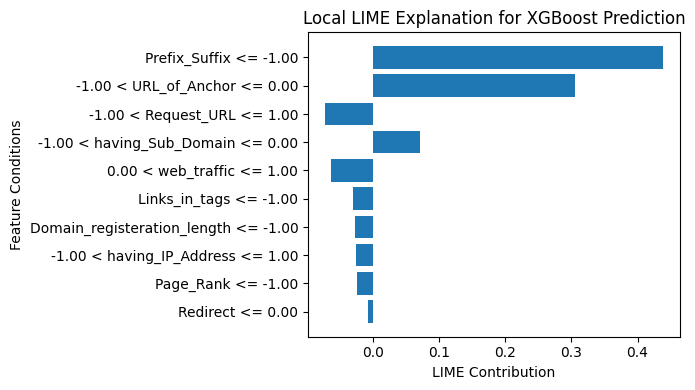

In [157]:
import matplotlib.pyplot as plt

exp = lime_explanation.as_list()

features = [x[0] for x in exp]
weights = [x[1] for x in exp]

plt.figure(figsize=(7,4))

plt.barh(
    features[::-1],
    weights[::-1]
)

plt.xlabel("LIME Contribution")
plt.ylabel("Feature Conditions")
plt.title("Local LIME Explanation for XGBoost Prediction")

plt.tight_layout()

plt.savefig(
    "Figure_8_LIME_Local_Explanation.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [59]:
# ============================================================
# Experiment 4: KNUST Trust Evaluation
# ============================================================

import pandas as pd
import numpy as np


KNUST_PATH = "/kaggle/input/datasets/awudipeter/knust-dataset/knust_dataset.csv"


knust = pd.read_csv(
    KNUST_PATH
)


print(knust.shape)

print(knust.head())

print(knust.columns)

(299, 36)
   Gender       Age_Group              Category          Experience  \
0  Female     18?25 years               Student  More than 10 years   
1    Male     18?25 years               Student  More than 10 years   
2  Female     26?35 years               Student    Less than 1 year   
3    Male  Above 45 years                 Other  More than 10 years   
4    Male     18?25 years  Administrative Staff           4?6 years   

        Verify_Links Familiar_Phishing Identify_Suspicious     Cyber_Training  \
0     Strongly Agree           Neutral      Strongly Agree  Strongly Disagree   
1     Strongly Agree             Agree      Strongly Agree            Neutral   
2  Strongly Disagree           Neutral               Agree  Strongly Disagree   
3  Strongly Disagree          Disagree               Agree     Strongly Agree   
4     Strongly Agree    Strongly Agree             Neutral           Disagree   

  Threat_to_Universities Respond_to_Phishing  ...         Trust_LIME  \
0   

In [60]:
# Dataset information

print(
    knust.info()
)


print(
    knust.describe()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Gender                         299 non-null    object
 1   Age_Group                      299 non-null    object
 2   Category                       299 non-null    object
 3   Experience                     299 non-null    object
 4   Verify_Links                   299 non-null    object
 5   Familiar_Phishing              299 non-null    object
 6   Identify_Suspicious            299 non-null    object
 7   Cyber_Training                 299 non-null    object
 8   Threat_to_Universities         299 non-null    object
 9   Respond_to_Phishing            299 non-null    object
 10  Received_Phishing_Email        299 non-null    object
 11  Lost_Info_Money                299 non-null    object
 12  Clicked_Suspicious_Link        299 non-null    object
 13  Repor

In [61]:
# ============================================================
# SHAP Trust Analysis
# ============================================================

shap_trust = knust[
    "Trust_AI_After_SHAP"
]


print(
shap_trust.describe()
)

count     299
unique      2
top        No
freq      160
Name: Trust_AI_After_SHAP, dtype: object


In [62]:
# ============================================================
# LIME Trust Analysis
# ============================================================

lime_trust = knust[
    "Trust_LIME"
]


print(
lime_trust.describe()
)

count                299
unique                 5
top       Strongly Agree
freq                  77
Name: Trust_LIME, dtype: object


In [63]:
# ============================================================
# Convert Trust Responses
# ============================================================

knust["Trust_AI_After_SHAP"] = knust[
    "Trust_AI_After_SHAP"
].map({

    "Yes": 1,
    "No": 0

})


knust["Trust_LIME"] = knust[
    "Trust_LIME"
].map({

    "Yes": 1,
    "No": 0

})

In [162]:
# ============================================================
# Clean SHAP Trust Responses
# ============================================================

knust["Trust_AI_After_SHAP"] = (
    knust["Trust_AI_After_SHAP"]
    .astype(str)
    .str.strip()
)

print(knust["Trust_AI_After_SHAP"].value_counts())

print(shap_summary)

Trust_AI_After_SHAP
0    160
1    139
Name: count, dtype: int64
       Mean  Median  Standard Deviation  Minimum  Maximum
0  0.464883     0.0            0.499601        0        1


In [168]:
# ============================================================
# Convert Trust_SHAP to Likert Scores
# ============================================================

likert_map = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5
}

knust["Trust_SHAP_Likert"] = (
    knust["Trust_SHAP"]
    .map(likert_map)
)

# Check conversion
print(knust["Trust_SHAP_Likert"].value_counts())

Trust_SHAP_Likert
3    70
1    63
4    57
2    55
5    54
Name: count, dtype: int64


In [169]:
# ============================================================
# SHAP Trust Likert Descriptive Statistics
# ============================================================

shap_summary = pd.DataFrame({
    "Mean": [
        knust["Trust_SHAP_Likert"].mean()
    ],
    "Median": [
        knust["Trust_SHAP_Likert"].median()
    ],
    "Standard Deviation": [
        knust["Trust_SHAP_Likert"].std()
    ],
    "Minimum": [
        knust["Trust_SHAP_Likert"].min()
    ],
    "Maximum": [
        knust["Trust_SHAP_Likert"].max()
    ]
})

print(shap_summary.round(3))

    Mean  Median  Standard Deviation  Minimum  Maximum
0  2.946     3.0               1.394        1        5


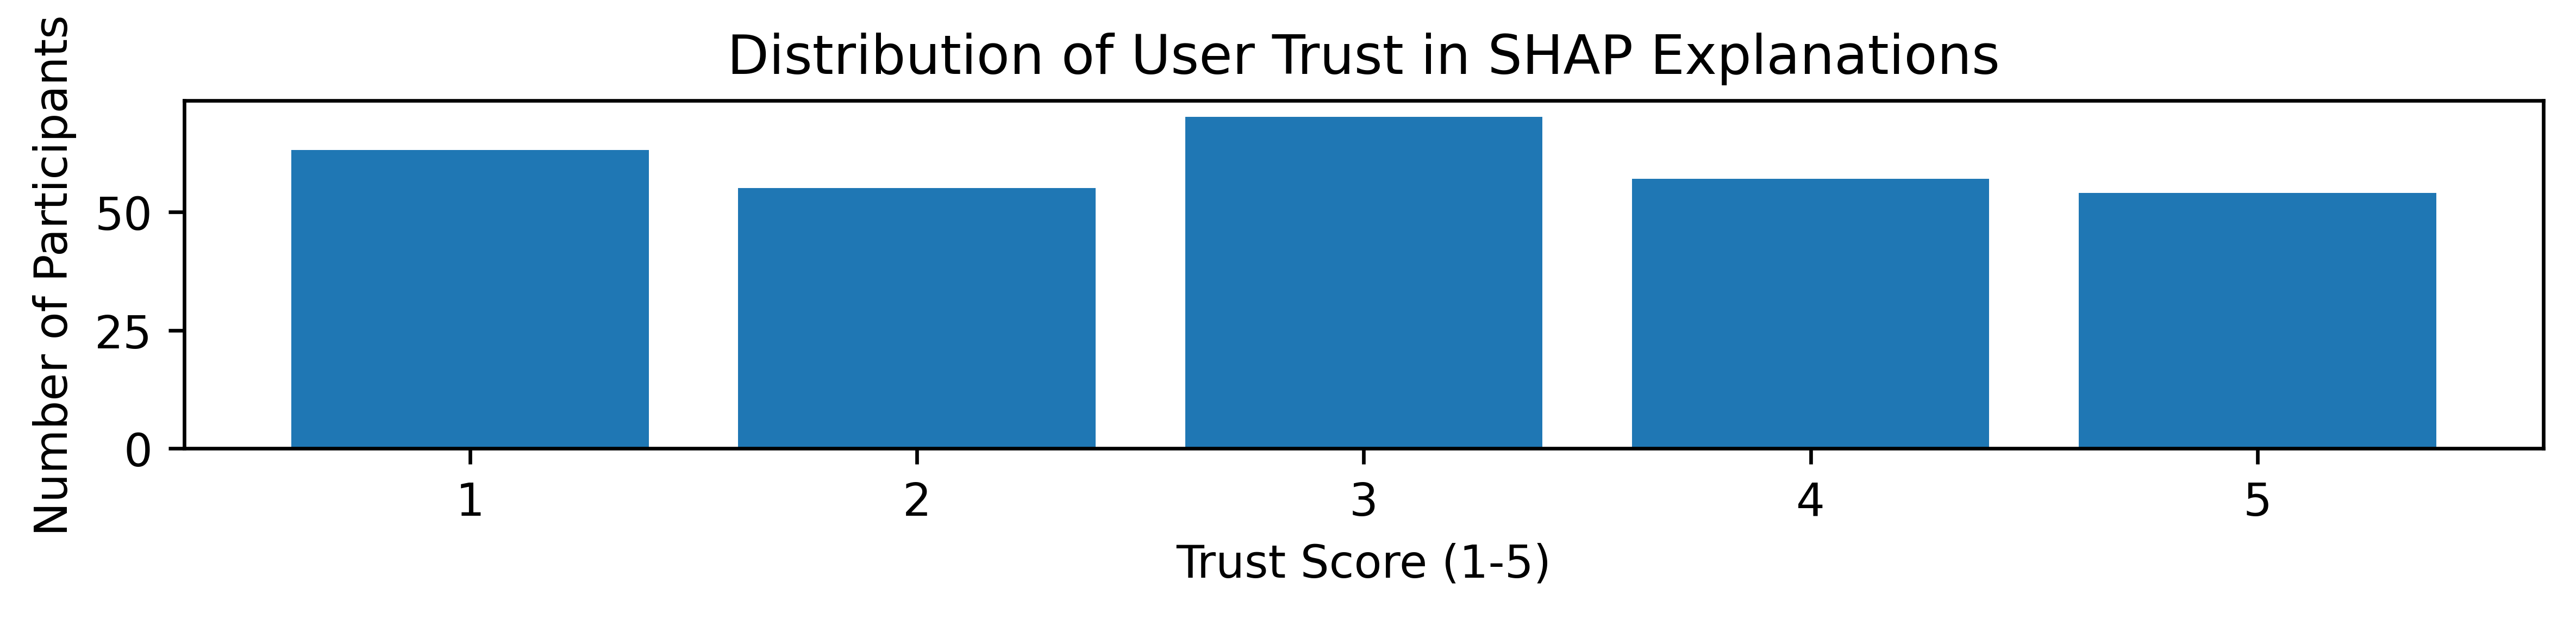

In [177]:
import matplotlib.pyplot as plt

# ============================================================
# SHAP Trust Distribution Plot
# ============================================================

trust_distribution = (
    knust["Trust_SHAP_Likert"]
    .value_counts()
    .sort_index()
)

plt.figure(
    figsize=(8,2),
    dpi=600
)

plt.bar(
    trust_distribution.index,
    trust_distribution.values
)

plt.xlabel(
    "Trust Score (1-5)"
)

plt.ylabel(
    "Number of Participants"
)

plt.title(
    "Distribution of User Trust in SHAP Explanations"
)

plt.xticks(
    [1, 2, 3, 4, 5]
)

plt.tight_layout()

plt.savefig(
    "SHAP_Trust_Distribution.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [178]:
# ============================================================
# Convert Overall AI Trust
# ============================================================

knust["Trust_AI_With_Explanations_Score"] = knust[
    "Trust_AI_With_Explanations"
].map({

    "Strongly Disagree": 1,

    "Disagree": 2,

    "Neutral": 3,

    "Agree": 4,

    "Strongly Agree": 5

})


print(
    knust["Trust_AI_With_Explanations_Score"].value_counts()
)

Trust_AI_With_Explanations_Score
4    82
5    59
2    56
1    54
3    48
Name: count, dtype: int64


In [183]:
# ============================================================
# Overall AI Trust Descriptive Statistics
# ============================================================

ai_trust_summary = pd.DataFrame({

    "Mean": [
        knust["Trust_AI_With_Explanations_Score"].mean()
    ],

    "Median": [
        knust["Trust_AI_With_Explanations_Score"].median()
    ],

    "Standard Deviation": [
        knust["Trust_AI_With_Explanations_Score"].std()
    ],

    "Minimum": [
        knust["Trust_AI_With_Explanations_Score"].min()
    ],

    "Maximum": [
        knust["Trust_AI_With_Explanations_Score"].max()
    ]

})


print(ai_trust_summary.round(3))

   Mean  Median  Standard Deviation  Minimum  Maximum
0  3.12     3.0               1.402        1        5


In [185]:
# ============================================================
# Trust Comparison
# ============================================================

trust_comparison = pd.DataFrame({

    "Measure": [
        "SHAP Explanation Trust",
        "AI Trust With Explanations"
    ],

    "Mean Score": [

        knust["Trust_SHAP_Likert"].mean(),

        knust["Trust_AI_With_Explanations_Score"].mean()

    ]

})


print(trust_comparison.round(3))

                      Measure  Mean Score
0      SHAP Explanation Trust       2.946
1  AI Trust With Explanations       3.120


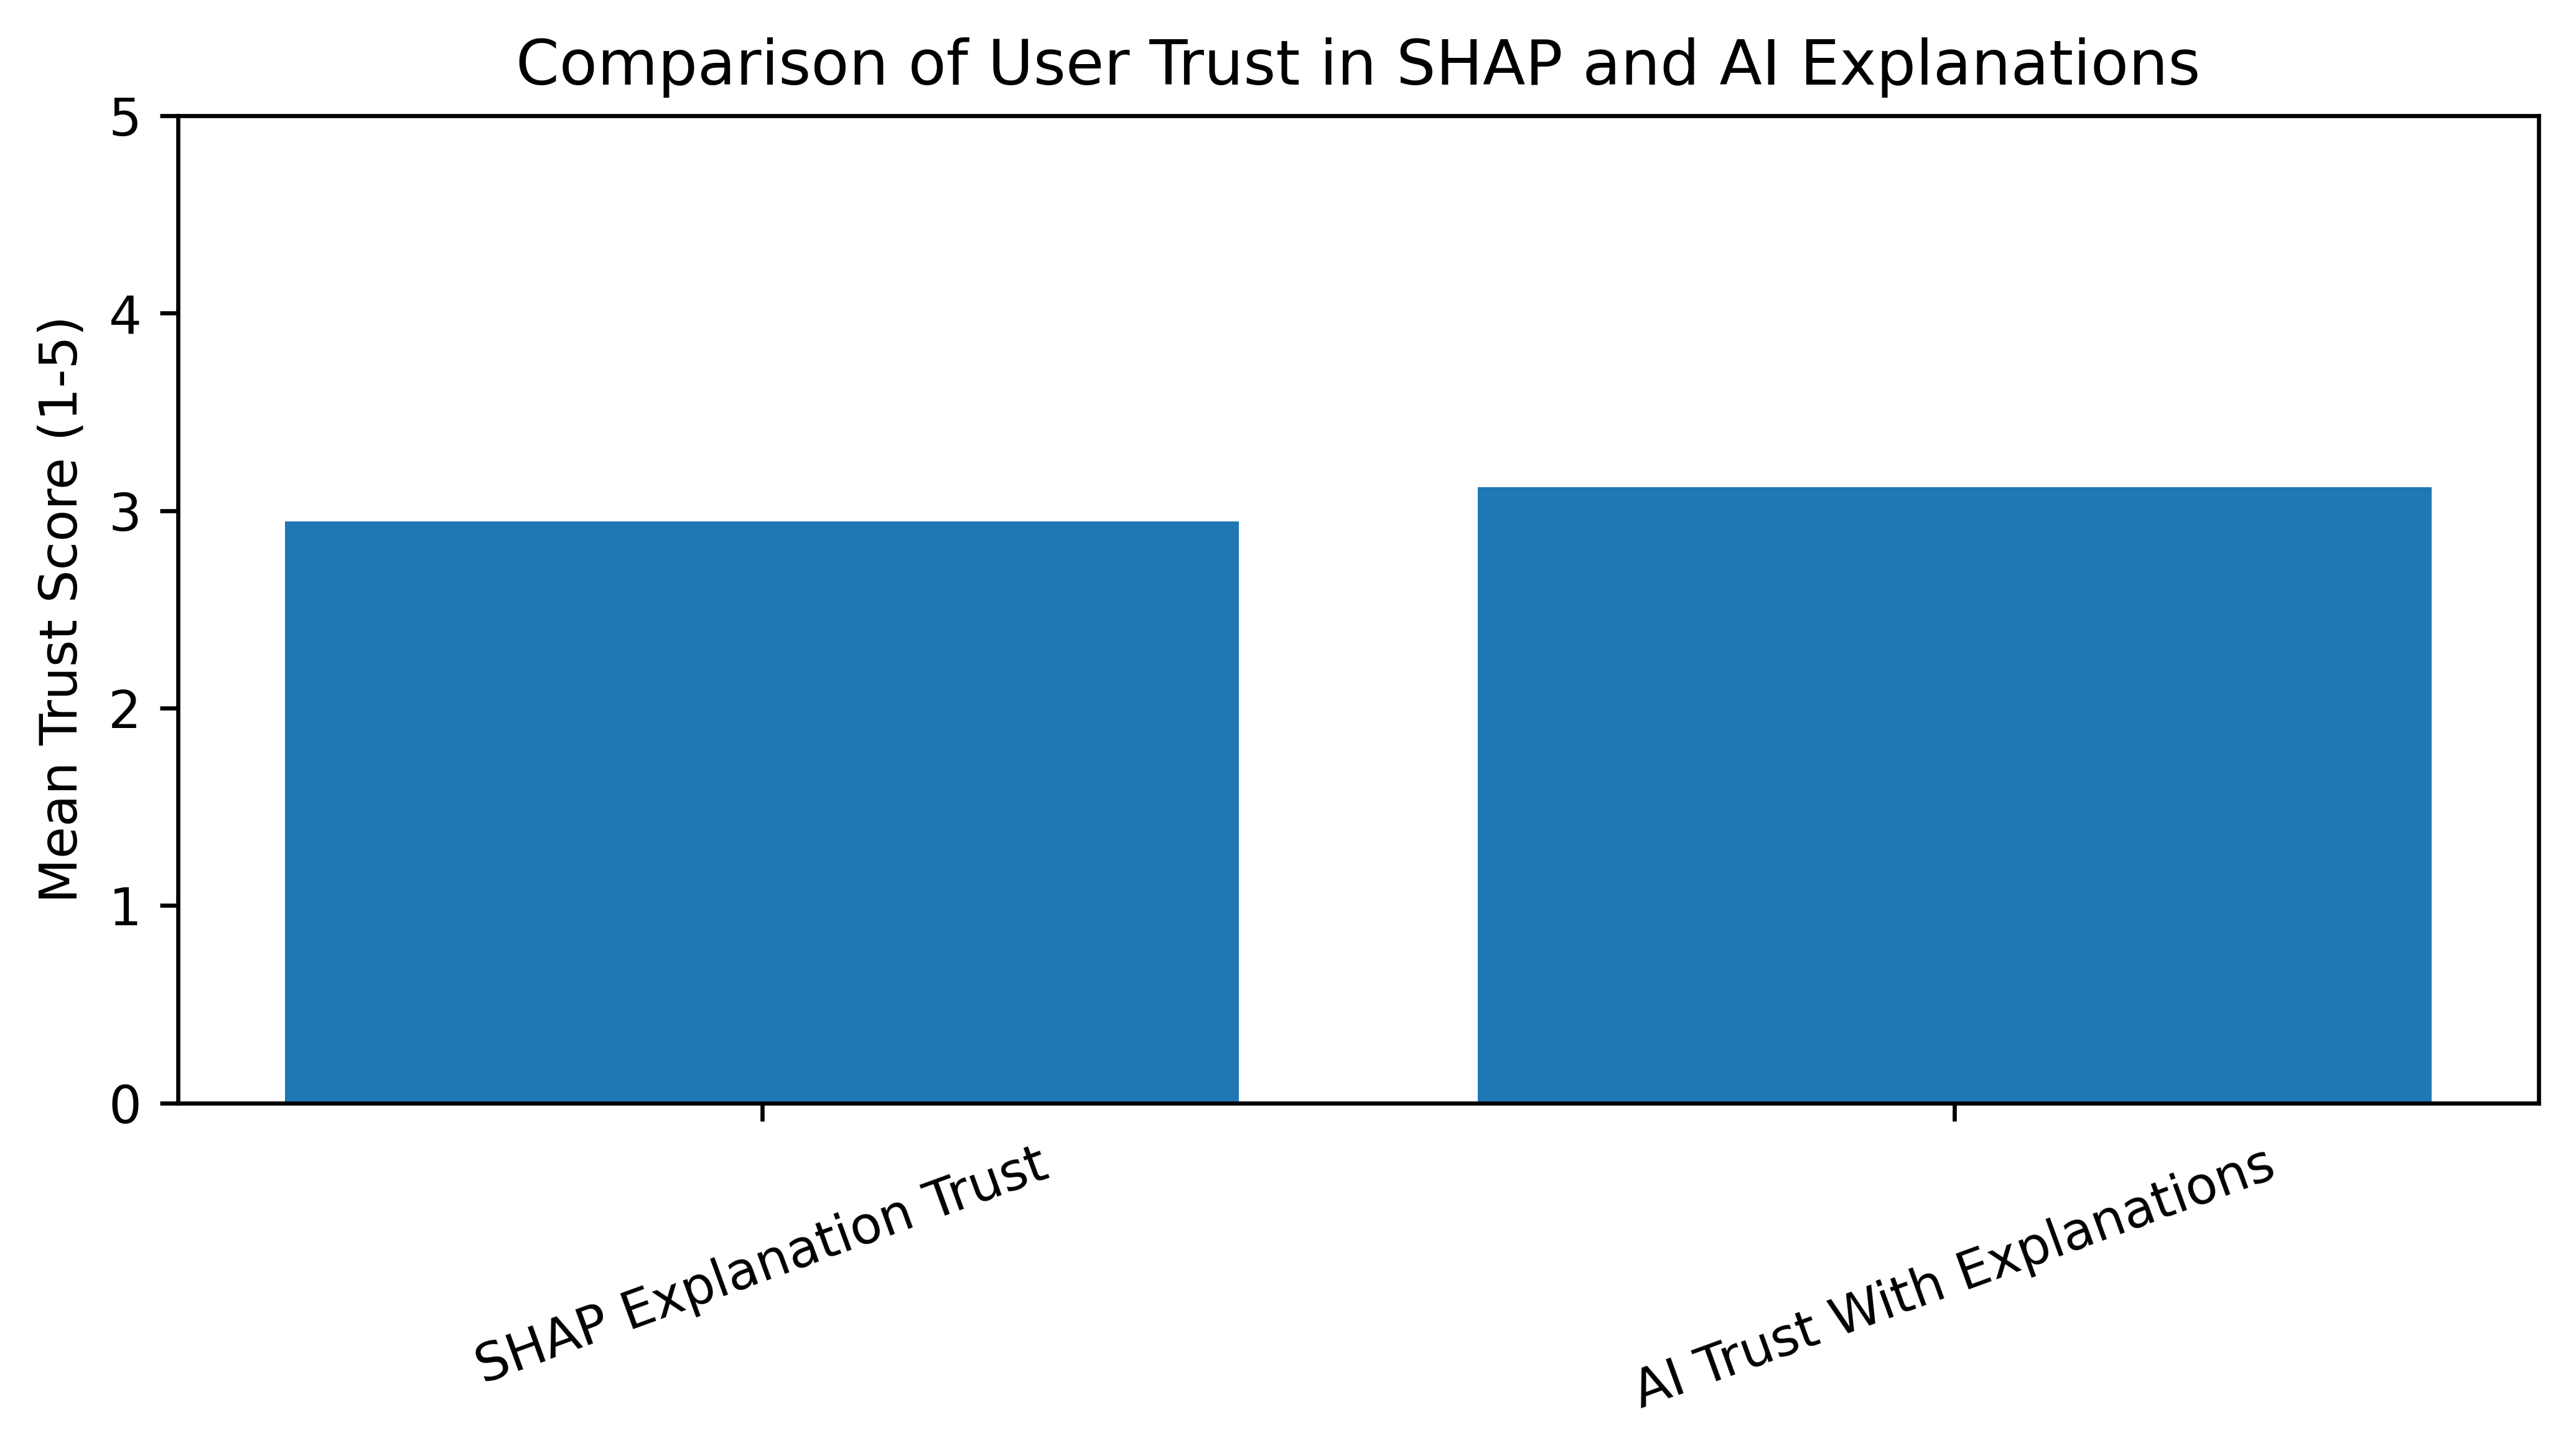

In [189]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(7,4),
    dpi=600
)

plt.bar(
    trust_comparison["Measure"],
    trust_comparison["Mean Score"]
)

plt.ylabel(
    "Mean Trust Score (1-5)"
)

plt.title(
    "Comparison of User Trust in SHAP and AI Explanations"
)

plt.xticks(
    rotation=20
)

plt.ylim(
    0,
    5
)

plt.tight_layout()

plt.savefig(
    "Trust_Comparison.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [190]:
# Search preference columns

preference_cols = [

    col for col in knust.columns

    if "prefer" in col.lower()
]


print(preference_cols)

['Prefer_Transparent_AI', 'Preferred_Explanation']


In [191]:
# ============================================================
# Explanation Preference Analysis
# ============================================================

preference = knust[
    "Preferred_Explanation"
].value_counts()


print(preference)

Preferred_Explanation
SHAP       84
LIME       77
Both       72
Neither    66
Name: count, dtype: int64


In [193]:
# ============================================================
# Preference Percentage
# ============================================================

preference_percentage = (
    preference /
    preference.sum()
) * 100


preference_table = pd.DataFrame({

    "Preference": preference.index,

    "Count": preference.values,

    "Percentage": preference_percentage.values.round(2)

})


print(preference_table)

  Preference  Count  Percentage
0       SHAP     84       28.09
1       LIME     77       25.75
2       Both     72       24.08
3    Neither     66       22.07


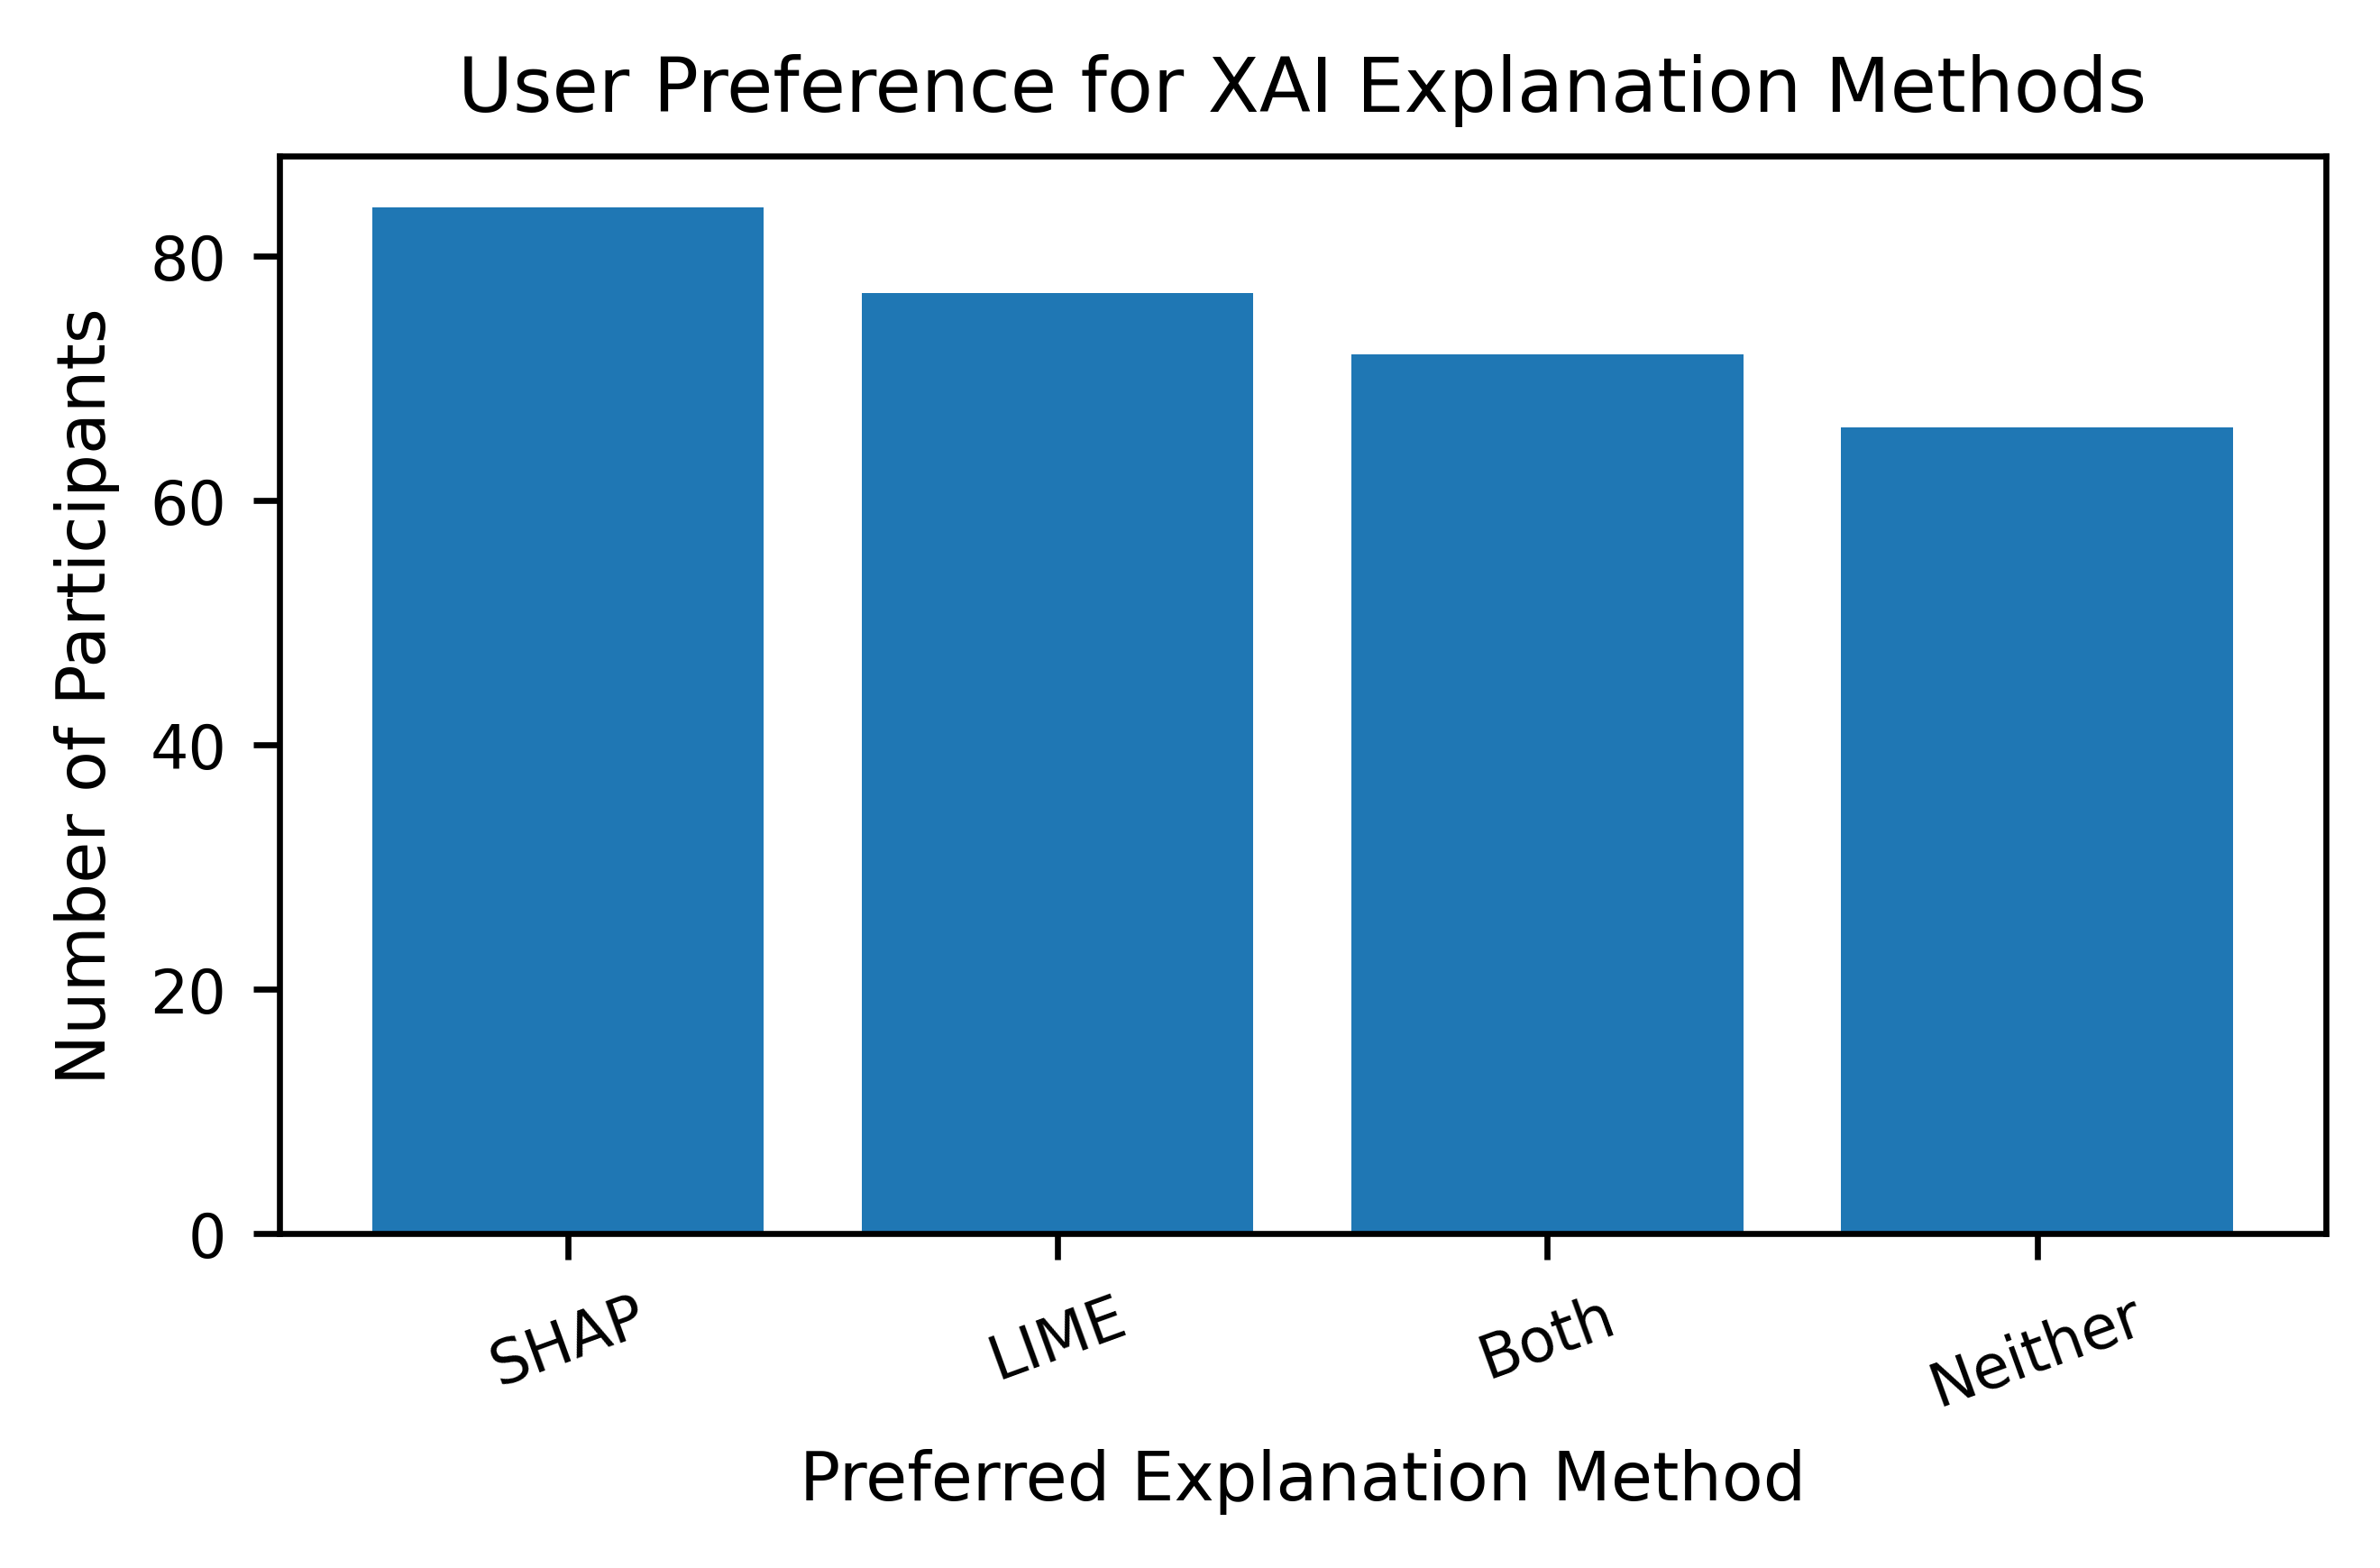

In [195]:
# ============================================================
# Preferred Explanation Plot (Reduced Size)
# ============================================================

import matplotlib.pyplot as plt

plt.figure(
    figsize=(4.5, 3),
    dpi=600
)

plt.bar(
    preference_table["Preference"],
    preference_table["Count"]
)

plt.xlabel(
    "Preferred Explanation Method",
    fontsize=9
)

plt.ylabel(
    "Number of Participants",
    fontsize=9
)

plt.title(
    "User Preference for XAI Explanation Methods",
    fontsize=10
)

plt.xticks(
    rotation=20,
    fontsize=8
)

plt.yticks(
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "Preferred_Explanation_Method.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [198]:
# ============================================================
# Create SHAP Trust Category
# ============================================================

knust["SHAP_Trust_Category"] = knust["Trust_SHAP_Likert"].map({

    1: "Low Trust",
    2: "Low Trust",
    3: "Neutral Trust",
    4: "High Trust",
    5: "High Trust"

})


print(knust["SHAP_Trust_Category"].value_counts())

SHAP_Trust_Category
Low Trust        118
High Trust       111
Neutral Trust     70
Name: count, dtype: int64


In [202]:
# ============================================================
# SHAP Trust Category vs Preferred Explanation
# Chi-square Test of Independence
# ============================================================

import pandas as pd
from scipy.stats import chi2_contingency

# Create contingency table
trust_preference = pd.crosstab(
    knust["SHAP_Trust_Category"],
    knust["Preferred_Explanation"]
)

print("Contingency Table:")
print(trust_preference)


# Chi-square test
chi2, p, dof, expected = chi2_contingency(
    trust_preference
)


print("\nChi-square:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", round(p, 5))

Contingency Table:
Preferred_Explanation  Both  LIME  Neither  SHAP
SHAP_Trust_Category                             
High Trust               21    33       22    35
Low Trust                36    27       26    29
Neutral Trust            15    17       18    20

Chi-square: 6.243
Degrees of freedom: 6
p-value: 0.39648


In [218]:
from scipy.stats import spearmanr

# Select relevant Likert-scale variables
corr_data = knust[
    ["Trust_SHAP_Likert", "AI_Trust_Score"]
].dropna()


corr, p_value = spearmanr(
    corr_data["Trust_SHAP_Likert"],
    corr_data["AI_Trust_Score"]
)


print("Spearman Correlation:", round(corr, 3))
print("p-value:", round(p_value, 5))

Spearman Correlation: -0.009
p-value: 0.87473
